In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import requests
import pandas as pd
from time import perf_counter

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---

In [2]:
def resolveKOI(KOI):
    # Resolve KOI -> Kepler ID / canonical name using Exo.MAST
    info = requests.get(
        "https://exo.mast.stsci.edu/api/v0.1/exoplanets/identifiers/",
        params={"name": KOI},
        timeout=30,
    ).json()
    
    # return info
    return info


___

In [3]:
KOICUMCAT = pd.read_csv(r"../assets/data/main/cumulative_2026.04.10_20.25.58_cleaned.csv")
KOICUMCAT.head()


,loc_rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,CANDIDATE,CANDIDATE,0.000,0,0,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


Getting the KIC for a specific KOI, i.e., get the LC of the star that this particular exoplanet orbits, and transits in front of.

In [4]:
sampleKOI = KOICUMCAT.loc[0]['kepoi_name']
sampleKOI


'K00752.01'

In [5]:
sampleInfo = resolveKOI(sampleKOI)


In [6]:
sampleInfo


{'canonicalName': 'Kepler-227 b',
 'starName': 'Kepler-227',
 'ra': 291.934236,
 'dec': 48.141651,
 'planetNames': ['2MASS J19274421+4808299 b',
  'Kepler-227 b',
  'KOI 752 b',
  'KIC 10797460 b'],
 'keplerID': 10797460,
 'keplerTCE': 'TCE_1',
 'tessID': 26539443,
 'tessTCE': None}

Shocker, most of these fields already have KeplerIDs, i.e., KICs? Thus, they don't need resolution.

---

In [7]:
sampleKIC = KOICUMCAT.loc[0]['kepid']
sampleKIC


np.int64(10797460)

In [8]:
search = lk.search_lightcurve(
    f"KIC {sampleKIC}",
    mission="Kepler"
)
search


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr010797460,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr010797460,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr010797460,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr010797460,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr010797460,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr010797460,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr010797460,0.0
7,Kepler Quarter 10,2011,Kepler,1800,kplr010797460,0.0
8,Kepler Quarter 09,2011,Kepler,1800,kplr010797460,0.0


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

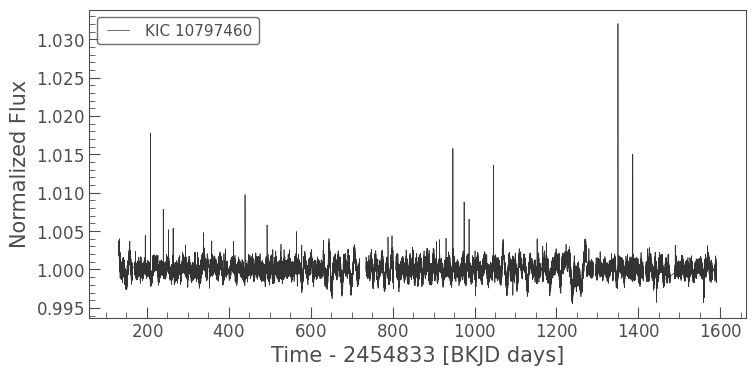

In [9]:
lc = search.download_all().stitch().normalize()
lc.plot()


---

In [10]:
listOfKICs = (
    KOICUMCAT['kepid']
    .dropna()
    .astype(int)
    .drop_duplicates()
    .tolist()
)


In [11]:
listOfKICs


[10797460,
 10811496,
 10848459,
 10854555,
 10872983,
 6721123,
 10910878,
 11446443,
 10666592,
 6922244,
 10984090,
 10419211,
 10464078,
 10480982,
 10485250,
 10526549,
 10583066,
 10583180,
 10601284,
 2306756,
 10662202,
 10682541,
 11460018,
 11463211,
 11465813,
 11493732,
 11507101,
 10987985,
 11018648,
 11138155,
 11152159,
 11153539,
 11242721,
 9579641,
 11304958,
 11391957,
 11403044,
 11414511,
 11442465,
 12110942,
 12366084,
 12404086,
 8395660,
 11656840,
 11754553,
 11812062,
 11818800,
 11853255,
 11909839,
 11918099,
 11923270,
 11960862,
 12020329,
 12066335,
 12070811,
 3120431,
 3246984,
 3342970,
 12459725,
 12470844,
 12644822,
 2440757,
 2445129,
 2713049,
 3114167,
 3114661,
 3115833,
 4139816,
 4275191,
 4476123,
 3351888,
 3453214,
 3554600,
 3641726,
 3734868,
 3832474,
 3836375,
 3838486,
 3935914,
 3940418,
 4049131,
 5287983,
 5358241,
 10875245,
 5358624,
 4544670,
 4664847,
 4725681,
 4913852,
 4932348,
 4936180,
 11913073,
 5021899,
 5077629,
 5115

In [12]:
len(listOfKICs)


8214